# GREA best-fit: H(z), w(z) and BAO distance plots

Loads a single Cobaya chain (GREA and, optionally, a matching ΛCDM chain for
comparison), gets the best-fit point (minimum `minuslogpost` sample) and a set of
weighted posterior draws, then:

1. Runs CLASS (background+thermodynamics only, `output=''`) at the best fit and at
   each draw to build `H(z)/(1+z)` and `w(z)` curves, with 1σ/2σ bands from the
   draws' pointwise percentiles.
2. Same for the BAO distance ratios `D_V/(r_d√z)`, `D_M/(r_d√z)`, `zD_H/(r_d√z)`,
   overlaid with DESI DR2 BAO measurements and a (data−model)/σ residual panel.

Run selection works the same way as `grea_pp_desi_analysis.ipynb`: point at a
folder, the notebook discovers every Cobaya run (`<root>.updated.yaml` + `.txt`
chains) under it, and you pick one by index/label.


In [1]:
from classy import Class
import os
import sys
import glob
import numpy as np

# ROOT detection: works whether Jupyter is launched from ANALYSIS/ (this
# notebook's expected home) or from the repo root.
_cwd = os.getcwd()
_CLASS_ROOT = None
for _candidate in [
    os.path.join(_cwd, "class_public-3.3.4"),        # cwd = repo root
    os.path.join(_cwd, "..", "class_public-3.3.4"),  # cwd = ANALYSIS/
]:
    if os.path.exists(os.path.join(_candidate, "source", "background.c")):
        _CLASS_ROOT = os.path.abspath(_candidate)
        break
if _CLASS_ROOT is None:
    raise RuntimeError(
        "Cannot find class_public-3.3.4/ near the current working directory. "
        "Start Jupyter from the repo root or from ANALYSIS/.")
ROOT = _CLASS_ROOT
sys.path.insert(0, os.path.join(ROOT, "python"))
print(f"CLASS ROOT = {ROOT}")


_C_KMS = 2.99792458e5  # speed of light, km/s

CLASS ROOT = /Users/simonedonofrio/Desktop/CLASS_GREA/class_public-3.3.4


In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from getdist import loadMCSamples

try:
    import scienceplots  # noqa: F401 -- registers the "science" style
    plt.style.use(["science"])
except ImportError:
    pass

IGNORE_ROWS = 0.3   # burn-in fraction removed at load time
OUT_DIR = "figs"
os.makedirs(OUT_DIR, exist_ok=True)

# Where to look for Cobaya runs. Mirrors grea_pp_desi_analysis.ipynb: GREA runs
# sit under ANALYSIS/ (this notebook's folder), LCDM comparison runs under
# ../lcdm_chains relative to it.
GREA_CHAINS_DIR = "."
LCDM_CHAINS_DIR = "../lcdm_chains"


def run_label(root, chains_dir):
    parts = os.path.relpath(root, chains_dir).split(os.sep)
    # cobaya 'chains/chains' prefix
    if len(parts) >= 2 and parts[-1] == parts[-2]:
        parts = parts[:-1]
    if len(parts) >= 2 and parts[-1] == "chains":       # trailing 'chains' dir
        parts = parts[:-1]
    return os.sep.join(parts) if parts else os.path.basename(root)


def discover_runs(chains_dir):
    runs = {}
    for y in sorted(glob.glob(os.path.join(chains_dir, "**", "*.updated.yaml"), recursive=True)):
        root = y[:-len(".updated.yaml")]
        has_chains = glob.glob(
            root + ".*.txt") or os.path.exists(root + ".txt")
        if not has_chains:
            continue
        runs[run_label(root, chains_dir)] = root
    return runs

## 1. Discover and pick runs

Set `GREA_RUN` / `LCDM_RUN` below to the label you want (see the printed lists).
`LCDM_RUN = None` skips the ΛCDM overlay entirely.

In [3]:
grea_runs = discover_runs(GREA_CHAINS_DIR)
lcdm_runs = discover_runs(LCDM_CHAINS_DIR)

print("GREA runs found:")
for i, label in enumerate(grea_runs):
    print(f"  [{i}] {label}")
print("\nLCDM runs found:")
for i, label in enumerate(lcdm_runs):
    print(f"  [{i}] {label}")

GREA runs found:
  [0] grea_Run1_PP+DESI
  [1] grea_Run2_CMB-SPA
  [2] grea_Run3_CMB-SPA+PP+DESI
  [3] grea_Run4_PPS+DESI
  [4] grea_Run5_CMB-SPA+PPS+DESI
  [5] grea_Run6_CMB-SPA+DESI
  [6] grea_Run7_CMB-SPA+PP
  [7] grea_Run8_CMB-SPA+DESDovekie
  [8] grea_Run9_CMB-SPA+DESDovekie+DESI
  [9] lcdm_CMB-SPA+DESDovekie+DESI/chains/ts_CMB-SPA+DD+DESI
  [10] lcdm_CMB-SPA+PP+DESI/chains/CMB-SPA+PP+DESI
  [11] lcdm_CMB-SPA+PPS+DESI/chains/CMB-SPA+PPS+DESI

LCDM runs found:
  [0] CMB-SPA+PP+DESI
  [1] CMB-SPA+PPS+DESI
  [2] CMB-SPA
  [3] DD+DESI
  [4] PP+DESI.posterior_mean
  [5] PP+DESI
  [6] PPS+DESI
  [7] ts_CMB-SPA+DD+DESI
  [8] ts_CMB-SPA+PP+DESI
  [9] ts_CMB-SPA


In [4]:
# --- pick the chains here -----------------------------------------------
GREA_RUN = list(grea_runs)[2]   # e.g. "grea_Run1_PP+DESI" -- edit to change
LCDM_RUN = list(lcdm_runs)[0]   # matching LCDM comparison run, or None to skip
# --------------------------------------------------------------------------

print("GREA run:", GREA_RUN, "->", grea_runs[GREA_RUN])
if LCDM_RUN is not None:
    print("LCDM run:", LCDM_RUN, "->", lcdm_runs[LCDM_RUN])

GREA run: grea_Run3_CMB-SPA+PP+DESI -> ./grea_Run3_CMB-SPA+PP+DESI/chains/chains
LCDM run: CMB-SPA+PP+DESI -> ../lcdm_chains/CMB-SPA+PP+DESI


## 2. Load chains + convergence

In [5]:
grea_s = loadMCSamples(grea_runs[GREA_RUN], settings={
                       "ignore_rows": IGNORE_ROWS})
print(f"{GREA_RUN}: {int(grea_s.numrows)} samples | R-1(worst) = {grea_s.getGelmanRubin():.4f}")

lcdm_s = None
if LCDM_RUN is not None:
    lcdm_s = loadMCSamples(lcdm_runs[LCDM_RUN], settings={
                           "ignore_rows": IGNORE_ROWS})
    print(f"{LCDM_RUN}: {int(lcdm_s.numrows)} samples | R-1(worst) = {lcdm_s.getGelmanRubin():.4f}")

grea_Run3_CMB-SPA+PP+DESI: 10396 samples | R-1(worst) = 0.0116
CMB-SPA+PP+DESI: 19678 samples | R-1(worst) = 0.0111


## 3. Best fit + posterior draws

"Best fit" = the chain sample with the lowest `minuslogpost` (max posterior
density), not the posterior mean. `N_DRAWS` weighted random samples are drawn
from the (burn-in-removed) chain to build the 1σ/2σ bands below -- raise it for
smoother bands at the cost of more CLASS calls.

In [6]:
def best_fit_and_draws(s, params, n_draws=150, seed=0):
    names = s.getParamNames().list()
    idx = [names.index(p) for p in params]
    samp = s.samples[:, idx]
    loglikes = s.loglikes
    weights = s.weights

    bf = dict(zip(params, samp[np.argmin(loglikes)]))

    rng = np.random.default_rng(seed)
    probs = weights / weights.sum()
    draw_idx = rng.choice(len(weights), size=n_draws, replace=True, p=probs)
    draws = [dict(zip(params, samp[i])) for i in draw_idx]
    return bf, draws


GREA_PARAMS = ["H0", "omega_b", "omega_cdm", "sqrt_k_eta0"]
LCDM_PARAMS = ["H0", "omega_b", "omega_cdm"]
N_DRAWS = 150

grea_bf, grea_draws = best_fit_and_draws(grea_s, GREA_PARAMS, n_draws=N_DRAWS)
print("GREA best fit:", grea_bf)

lcdm_bf = None
if lcdm_s is not None:
    lcdm_bf, _ = best_fit_and_draws(lcdm_s, LCDM_PARAMS, n_draws=N_DRAWS)
    print("LCDM best fit:", lcdm_bf)

GREA best fit: {'H0': np.float64(67.900117), 'omega_b': np.float64(0.022416292), 'omega_cdm': np.float64(0.11873014), 'sqrt_k_eta0': np.float64(3.3205036)}
LCDM best fit: {'H0': np.float64(68.146533), 'omega_b': np.float64(0.022479933), 'omega_cdm': np.float64(0.11848576)}


## 4. CLASS background helper

Background+thermodynamics only (`output=''`): fast, and all we need for
`H(z)`, `w(z)`, `D_M`, `D_H`, `D_V`, `r_d`. `_COMMON` mirrors the fixed
`classy` settings baked into the Cobaya run yamls (`N_ncdm`, `N_ur`, `m_ncdm`,
sBBN table); `tau_reio`/`A_s`/`n_s` are irrelevant to the background and just
need *some* valid value.

In [7]:
_COMMON = {
    "N_ncdm": 1, "N_ur": 2.046, "m_ncdm": 0.06,
    "sBBN file": "external/bbn/sBBN_2017.dat",
    "base_path": ROOT + "/",
    "tau_reio": 0.06, "A_s": 2.1e-9, "n_s": 0.9649,
    "output": "",
}


def build_grea(p):
    c = Class()
    c.set({**_COMMON, "fluid_equation_of_state": "GREA", "cs2_fld": 1.0, "use_ppf": "yes",
           "H0": p["H0"], "omega_b": p["omega_b"], "omega_cdm": p["omega_cdm"],
           "sqrt_k_eta0": p["sqrt_k_eta0"]})
    c.compute()
    return c


def build_lcdm(p):
    c = Class()
    c.set(
        {**_COMMON, "H0": p["H0"], "omega_b": p["omega_b"], "omega_cdm": p["omega_cdm"]})
    c.compute()
    return c


def curves(c, z_grid):
    """H(z)/(1+z) [km/s/Mpc], w(z), D_M(z), D_H(z), D_V(z) [Mpc], r_d [Mpc]."""
    bg = c.get_background()
    z_bg = np.array(bg["z"])
    order = np.argsort(z_bg)
    z_bg = z_bg[order]
    H_bg = np.array(bg["H [1/Mpc]"])[order] * _C_KMS
    w_bg = np.array(bg["(.)w_fld"])[
        order] if "(.)w_fld" in bg else -np.ones_like(z_bg)

    Hz = np.interp(z_grid, z_bg, H_bg)
    wz = np.interp(z_grid, z_bg, w_bg)
    DH = _C_KMS / Hz
    DM = np.array([c.comoving_distance(z) for z in z_grid])
    DV = (z_grid * DM**2 * DH) ** (1.0 / 3.0)
    rd = c.rs_drag()
    c.struct_cleanup()
    return dict(Hz_over_1pz=Hz / (1.0 + z_grid), w=wz, DM=DM, DH=DH, DV=DV, rd=rd)


Z_GRID = np.linspace(1e-3, 2.6, 200)

## 5. Compute best-fit curves + 1σ/2σ bands

This is the slow cell: one CLASS call for the best fit, plus `N_DRAWS` calls
for the bands. A few minutes for `N_DRAWS = 150`.

In [8]:
print("Best-fit GREA curve...")
grea_bf_curves = curves(build_grea(grea_bf), Z_GRID)

lcdm_bf_curves = None
if lcdm_bf is not None:
    print("Best-fit LCDM curve...")
    lcdm_bf_curves = curves(build_lcdm(lcdm_bf), Z_GRID)

print(f"{N_DRAWS} GREA posterior draws for the bands...")
draw_stack = {k: [] for k in ["Hz_over_1pz", "w", "DM", "DH", "DV"]}
for i, p in enumerate(grea_draws):
    cv = curves(build_grea(p), Z_GRID)
    for k in draw_stack:
        draw_stack[k].append(cv[k])
    if (i + 1) % 25 == 0:
        print(f"  {i + 1}/{N_DRAWS}")
draw_stack = {k: np.array(v) for k, v in draw_stack.items()}


def pct_bands(arr):
    return dict(
        lo2=np.percentile(arr, 2.5, axis=0), lo1=np.percentile(arr, 16, axis=0),
        hi1=np.percentile(arr, 84, axis=0), hi2=np.percentile(arr, 97.5, axis=0),
    )


grea_bands = {k: pct_bands(v) for k, v in draw_stack.items()}
print("Done.")

Best-fit GREA curve...
Best-fit LCDM curve...
150 GREA posterior draws for the bands...
  25/150
  50/150
  75/150
  100/150
  125/150
  150/150
Done.


## 6. DESI DR2 BAO measurements

Consensus (`GCcomb`) BAO distance-ratio measurements, one row per tracer,
cross-checked against three independent sources before use:

1. The exact data file this repo's own Cobaya likelihood config already
   points to (`lcdm_chains/*.updated.yaml` -> `bao.desi_dr2` ->
   `bao_data/desi_bao_dr2/desi_gaussian_bao_ALL_GCcomb_mean.txt` + `_cov.txt`),
   from [CobayaSampler/bao_data](https://github.com/CobayaSampler/bao_data/tree/master/desi_bao_dr2).
   1-sigma errors below are `sqrt(diag(cov))` from that covariance file.
2. Table 4 of the DESI DR2 BAO paper itself (arXiv:2503.14738), read directly
   off the rendered HTML -- values agree with (1) to the last quoted digit.
3. Independent citations of the same table in later papers (e.g. the Lya
   D_M/r_d = 38.99 +/- 0.52 point quoted standalone elsewhere), which match too.

Off-diagonal `D_M`-`D_H` correlations per tracer are *not* applied here (the
error bars plotted are marginal 1D errors, not a full correlated fit) --
correlation coefficients are ~-0.35 to -0.49 per tracer if you want to add
that later. Note DR2 upgraded QSO to a full anisotropic `D_M/r_d`, `D_H/r_d`
split (DR1 only had `D_V/r_d` for QSO) -- only BGS remains isotropic-only.

In [9]:
# tracer -> effective redshift + measured ratios (isotropic D_V/r_d and/or
# anisotropic D_M/r_d, D_H/r_d) with their 1-sigma uncertainties.
# Source: github.com/CobayaSampler/bao_data/tree/master/desi_bao_dr2
#   (desi_gaussian_bao_ALL_GCcomb_mean.txt + _cov.txt), matching Table 4 of
#   arXiv:2503.14738 to the last quoted digit -- cross-checked 2026-07-09.

DESI_BAO = {
    "BGS":       dict(z=0.295, DV_rd=7.94168,  sDV=0.07609),
    "LRG1":      dict(z=0.510, DV_rd=12.7200,  sDV=0.09900, DM_rd=13.58758, sDM=0.16837, DH_rd=21.86295, sDH=0.42887),
    "LRG2":      dict(z=0.706, DV_rd=16.0500,  sDV=0.11000, DM_rd=17.35069, sDM=0.17993, DH_rd=19.45535, sDH=0.33387),
    "LRG3+ELG1": dict(z=0.934, DV_rd=19.7210,  sDV=0.09100, DM_rd=21.57564, sDM=0.16178, DH_rd=17.64149, sDH=0.20104),
    "ELG2":      dict(z=1.321, DV_rd=24.2520,  sDV=0.17400, DM_rd=27.60086, sDM=0.32456, DH_rd=14.17602, sDH=0.22455),
    "QSO":       dict(z=1.484, DV_rd=26.0550,  sDV=0.39800, DM_rd=30.51190, sDM=0.76356, DH_rd=12.81700, sDH=0.51801),
    "Lya":       dict(z=2.330, DV_rd=31.2670,  sDV=0.25600, DM_rd=38.98897, sDM=0.53168, DH_rd=8.63155,  sDH=0.10106),
}


def desi_Hz_over_1pz(entry, rd_Mpc):
    """Convert a D_H/r_d measurement to H(z)/(1+z) [km/s/Mpc] using an
    assumed r_d [Mpc] (model-dependent: anchored here to the GREA best fit)."""
    if "DH_rd" not in entry:
        return None, None
    H = _C_KMS / (entry["DH_rd"] * rd_Mpc)
    sH = H * (entry["sDH"] / entry["DH_rd"])
    return H / (1.0 + entry["z"]), sH / (1.0 + entry["z"])

## 7. Plot 1 -- $H(z)/(1+z)$ and $w(z)$

saved -> figs/bestfit_Hz_wz.pdf


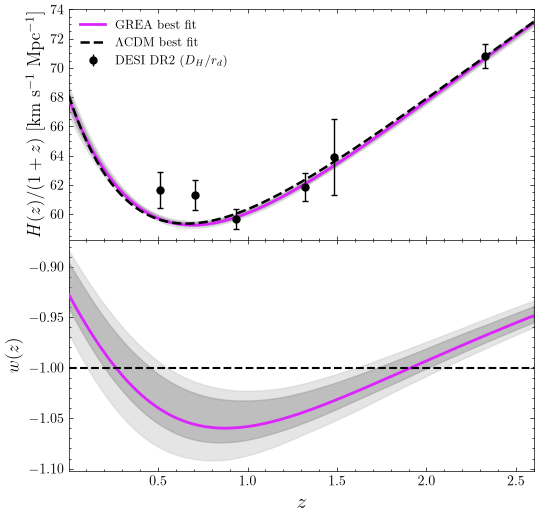

In [15]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6., 6.), sharex=True,
    gridspec_kw={"height_ratios": [1., 1], "hspace": 0.0},
)

ax1.fill_between(Z_GRID, grea_bands["Hz_over_1pz"]["lo2"], grea_bands["Hz_over_1pz"]["hi2"],
                 color="0.8", alpha=0.5, zorder=1)
ax1.fill_between(Z_GRID, grea_bands["Hz_over_1pz"]["lo1"], grea_bands["Hz_over_1pz"]["hi1"],
                 color="0.6", alpha=0.5, zorder=2)
ax1.plot(Z_GRID, grea_bf_curves["Hz_over_1pz"], color="#DC24FF", lw=2,
         label="GREA best fit", zorder=3)
if lcdm_bf_curves is not None:
    ax1.plot(Z_GRID, lcdm_bf_curves["Hz_over_1pz"], color="k", lw=1.8, ls="--",
             label=r"$\Lambda$CDM best fit", zorder=3)

# DESI DR2 D_H/r_d points, converted to H(z)/(1+z) anchored at the GREA best-fit r_d.
rd_bf = grea_bf_curves["rd"]
for name, e in DESI_BAO.items():
    h, he = desi_Hz_over_1pz(e, rd_bf)
    if h is not None:
        ax1.errorbar(e["z"], h, yerr=he, fmt="o",
                     color="k", ms=5, capsize=2, zorder=5)
ax1.errorbar([], [], yerr=[], fmt="o", color="k", ms=5, capsize=2,
             label=r"DESI DR2 ($D_H/r_d$)")  # single legend entry

ax1.set_ylabel(r"$H(z)/(1+z)$  [km s$^{-1}$ Mpc$^{-1}$]", fontsize=13)
ax1.legend(loc="upper left", fontsize=9)
# ax1.grid(alpha=0.3)

ax2.fill_between(Z_GRID, grea_bands["w"]["lo2"],
                 grea_bands["w"]["hi2"], color="0.8", alpha=0.5, zorder=1)
ax2.fill_between(Z_GRID, grea_bands["w"]["lo1"],
                 grea_bands["w"]["hi1"], color="0.6", alpha=0.5, zorder=2)
ax2.plot(Z_GRID, grea_bf_curves["w"], color="#DC24FF", lw=2, zorder=3)
ax2.axhline(-1.0, color="k", lw=1.5, ls="--", zorder=3)
ax2.set_ylabel(r"$w(z)$", fontsize=13)
ax2.set_xlabel(r"$z$", fontsize=15)
# ax2.grid(alpha=0.3)
ax2.set_xlim(Z_GRID[0], Z_GRID[-1])

fig.savefig(os.path.join(OUT_DIR, "bestfit_Hz_wz.pdf"),
            dpi=300, bbox_inches="tight")
print("saved -> figs/bestfit_Hz_wz.pdf")
plt.show()

## 8. Plot 2 -- BAO distance plot

`D_V(z)/(r_d\sqrt z)`, `D_M(z)/(r_d\sqrt z)`, `zD_H(z)/(r_d\sqrt z)` for the
GREA best fit (solid) and ΛCDM best fit (dashed), with DESI DR2 points and a
`(data − model)/σ` residual panel (× = GREA, ○ = ΛCDM).

saved -> figs/bestfit_distances_BAO.pdf


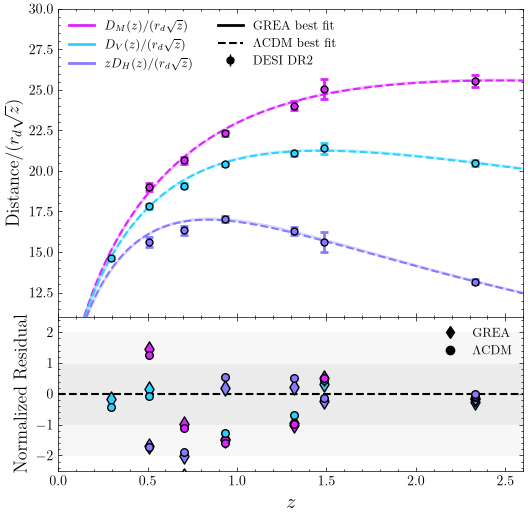

In [18]:
def curve_ratios(cv, z_grid):
    rd = cv["rd"]
    return dict(
        DV=cv["DV"] / (rd * np.sqrt(z_grid)),
        DM=cv["DM"] / (rd * np.sqrt(z_grid)),
        zDH=z_grid * cv["DH"] / (rd * np.sqrt(z_grid)),
    )


grea_ratio = curve_ratios(grea_bf_curves, Z_GRID)
lcdm_ratio = curve_ratios(
    lcdm_bf_curves, Z_GRID) if lcdm_bf_curves is not None else None

# COL = {"DV": "#1f77b4", "DM": "#8b1a1a", "zDH": "#2ca02c"}
COL = {"DV": "#2CD2FF", "DM": "#DC24FF", "zDH": "#847BFF"}

LAB = {"DV": r"$D_V(z)/(r_d\sqrt{z})$", "DM": r"$D_M(z)/(r_d\sqrt{z})$",
       "zDH": r"$zD_H(z)/(r_d\sqrt{z})$"}

fig, (axd, axr) = plt.subplots(
    2, 1, figsize=(6, 6), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.0},
)

style_handles = []

if lcdm_ratio is not None:
    for key in ("DM", "DV", "zDH"):
        axd.plot(Z_GRID, lcdm_ratio[key],
                 color=COL[key], ls="--", lw=1.5, zorder=2)
for key in ("DM", "DV", "zDH"):
    axd.plot(Z_GRID, grea_ratio[key], color=COL[key],
             lw=2, zorder=1, alpha=0.3)
    style_handles.append(
        Line2D([0], [0],  color=COL[key], lw=2, label=LAB[key], zorder=1, alpha=1))

axd.errorbar([], [], yerr=[], fmt="o", color="k", ms=5, capsize=2,
             label=r"DESI DR2")  # single legend entry


style_handles.append(Line2D([0], [0], color="k", lw=2, label="GREA best fit"))
if lcdm_ratio is not None:
    style_handles.append(
        Line2D([0], [0], color="k", lw=1.5, ls="--", label=r"$\Lambda$CDM best fit"))


def model_ratio_at(z, ratio_dict, key):
    return np.interp(z, Z_GRID, ratio_dict[key])


for name, e in DESI_BAO.items():
    z = e["z"]
    pts = []
    if "DV_rd" in e:
        pts.append(("DV", e["DV_rd"] / np.sqrt(z), e["sDV"] / np.sqrt(z)))
    if "DM_rd" in e:
        pts.append(("DM", e["DM_rd"] / np.sqrt(z), e["sDM"] / np.sqrt(z)))
    if "DH_rd" in e:
        pts.append(("zDH", z * e["DH_rd"] / np.sqrt(z),
                   z * e["sDH"] / np.sqrt(z)))
    for key, y, ye in pts:
        axd.errorbar(z, y, yerr=ye, fmt="o", color=COL[key], ms=5, mec="k",
                     capsize=3, zorder=5, elinewidth=2, capthick=2)
        axr.scatter(z, (y - model_ratio_at(z, grea_ratio, key)) / ye,
                    marker="d", edgecolor="k", color=COL[key], s=60, zorder=3)
        if lcdm_ratio is not None:
            axr.scatter(z, (y - model_ratio_at(z, lcdm_ratio, key)) / ye,
                        marker="o", facecolor=COL[key], edgecolor="k", s=30,
                        alpha=1., zorder=4)

axr.axhline(0, color="k", lw=1.5, ls="--", zorder=1)
axr.axhspan(-1, 1, color="0.92", zorder=0)
axr.axhspan(-2, -1, color="0.97", zorder=0)
axr.axhspan(1, 2, color="0.97", zorder=0)
axr.set_ylabel(r"(data $-$ model)/$\sigma$")
axr.set_ylabel(r"Normalized Residual", fontsize=13)


axr.set_xlabel(r"$z$", fontsize=15)
axr.legend(handles=[Line2D([0], [0], marker="d", color="k", lw=0, label="GREA"),
                    Line2D([0], [0], marker="o", color="k", lw=0, label=r"$\Lambda$CDM")],
           fontsize=9, loc="upper right")

axd.set_ylabel(r"Distance$/(r_d\sqrt{z})$", fontsize=13)
axd.legend(handles=style_handles + axd.get_legend_handles_labels()[
           0],  fontsize=9, loc="upper left", ncol=2)


axr.set_ylim(-2.5, 2.5)

axd.set_ylim(11, 30)
axd.set_xlim(0.0, 2.6)

fig.savefig(os.path.join(OUT_DIR, "bestfit_distances_BAO.pdf"),
            dpi=300, bbox_inches="tight")
print("saved -> figs/bestfit_distances_BAO.pdf")
plt.show()

## Notes

- **Best fit vs. posterior mean.** `best_fit_and_draws` uses the minimum
  `minuslogpost` chain sample, i.e. the maximum a posteriori sample actually
  visited by the chain -- not a dedicated Cobaya `minimize` run. If a
  `<root>.bestfit`/`.minimum` file exists for a run (some `lcdm_chains/*`
  runs have one), swapping to that would give a cleaner point estimate.
- **Bands.** 1σ/2σ bands are pointwise 16/84 and 2.5/97.5 percentiles of
  `N_DRAWS` weighted posterior draws run through CLASS -- a functional
  (not parameter-space) credible band. Raise `N_DRAWS` for smoother bands.
- **DESI DR2 table.** Placeholder values in the "DESI DR2 BAO measurements"
  cell -- verify against arXiv:2503.14738 (Table 1, `GCcomb`) before trusting
  the overlay or residuals.
- **r_d anchor for the H(z) overlay.** Converting a `D_H/r_d` measurement to
  a physical `H(z)` requires assuming *some* r_d; this notebook uses the GREA
  best-fit r_d, so the DESI points in Plot 1 are (mildly) model-dependent --
  standard practice for this kind of overlay, but worth flagging in a caption.
